# Fine-Tuning Analysis

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [2]:
train_df = np.load("embeddings/train_embeddings.npz")

test_df = np.load("embeddings/test_embeddings.npz")

Want to have embeddings -- claim count -- exposure

In [3]:
meta_train = [train_df['y'], train_df['w']]

In [4]:
# Partition Data
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=100).set_output(transform='pandas')

# Pipeline Execution
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Reconstruction
# Because indices are preserved, pandas aligns rows automatically.
# We can also rename columns cleanly if we want "PC1" instead of "pca0"

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(100)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

# Concatenate (Join)
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test = pd.concat([X_test_pca, meta_test], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 500000
Reduced Predictors:  100
Final Train Shape:   (500000, 102)
         PC1        PC2        PC3        PC4       PC5       PC6       PC7  \
0 -46.882321   0.978818   2.309586  14.796557 -5.479219 -3.145223  6.019113   
1 -20.297078   3.621709  -4.535339  -4.592134  4.301167  7.389555  6.040114   
2 -20.261710   3.616076  -4.557486  -4.649155  4.308381  7.441141  6.026612   
3 -11.187872  -1.913428  -1.496228 -13.345908  1.838406  5.136989  1.640864   
4 -17.405636  16.110668 -11.707022 -10.755758  2.353018  3.738804  8.182195   

         PC8       PC9      PC10  ...      PC93      PC94      PC95      PC96  \
0   0.266387 -0.477990 -2.233795  ... -0.363135  0.175988  0.805578 -0.823039   
1 -14.157145 -3.682525 -6.735758  ...  0.051431 -1.254098  0.648742  0.990075   
2 -14.182033 -3.694437 -6.744358  ...  0.055762 -1.276482  0.644995  1.011722   
3   6.515067  0.334644  4.692649  ... -0.259007  0.290391  0.646446 -2.006777   
4 -11.507573 -7.664805 -3.599086

In [5]:
# Extract Variance Proportions
ex_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(ex_var_ratio)

# Create a Summary DataFrame
df_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(ex_var_ratio))],
    'Individual_Variance': ex_var_ratio*100,
    'Cumulative_Variance': cum_var_ratio*100
})

df_variance

,Component,Individual_Variance,Cumulative_Variance
0,PC1,10.385540,10.385540
1,PC2,8.486269,18.871809
2,PC3,7.001964,25.873773
3,PC4,6.286408,32.160181
4,PC5,5.486295,37.646476
...,...,...,...
95,PC96,0.063063,96.699123
96,PC97,0.062194,96.761318
97,PC98,0.059962,96.821280
98,PC99,0.057543,96.878823


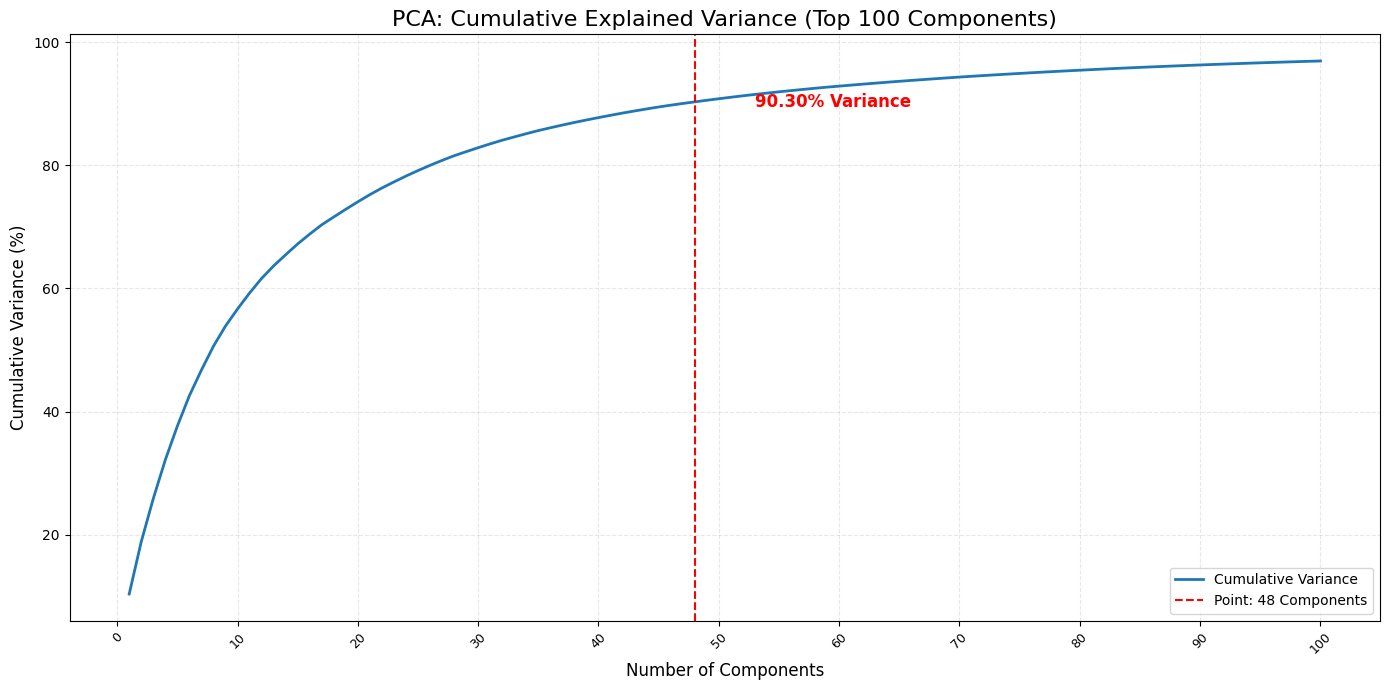

In [6]:
# Filter the data to the first 500 components
df_subset = df_variance

# Extract the variance explained by exactly 48 components
# Since Python is 0-indexed, PC48 is at index 47
var_at_48 = df_subset.iloc[47]['Cumulative_Variance']

# Set up the figure
plt.figure(figsize=(14, 7))

# Plot the cumulative variance curve
plt.plot(range(1, len(df_subset) + 1), df_subset['Cumulative_Variance'], 
         color='tab:blue', linewidth=2, label='Cumulative Variance')

# Add a vertical line at 48 components
plt.axvline(x=48, color='red', linestyle='--', linewidth=1.5, label='Point: 48 Components')

# Add a text label showing the variance explained at n=48
# We offset the x position slightly (+5) so the text doesn't sit on the line
plt.text(48 + 5, var_at_48, f'{var_at_48:.2f}% Variance', 
         color='red', fontweight='bold', fontsize=12, verticalalignment='center')

# Set x-axis ticks to show every 10th component for clarity
plt.xticks(range(0, 101, 10), rotation=45, fontsize=9)

# Formatting labels and title
plt.title('PCA: Cumulative Explained Variance (Top 100 Components)', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Adjust layout and show
plt.tight_layout()
#plt.savefig('var_curve.png')
plt.show()

In [7]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_train.shape[1])]

# Create the DataFrame
X_train = pd.DataFrame(X_train, columns=col_names, copy=False)

print(X_train.head())

   embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
0    -0.026321    -0.024597    -0.012703     0.048828     0.084473   
1    -0.020142    -0.031494    -0.012863     0.052155     0.080872   
2    -0.020111    -0.031586    -0.012856     0.052155     0.080811   
3    -0.020584    -0.033051    -0.012680     0.062012     0.088257   
4    -0.024811    -0.028458    -0.012703     0.056000     0.085815   

   embedding_6  embedding_7  embedding_8  embedding_9  embedding_10  ...  \
0    -0.027359     0.026047     0.001639    -0.028870     -0.001220  ...   
1    -0.020142     0.007397     0.004749    -0.024170      0.006325  ...   
2    -0.020111     0.007362     0.004486    -0.024155      0.006329  ...   
3    -0.013855     0.001756     0.013229    -0.009872      0.004837  ...   
4    -0.016129     0.001112     0.010109    -0.021210      0.007431  ...   

   embedding_1015  embedding_1016  embedding_1017  embedding_1018  \
0        0.021027        0.004387        0.003538    

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [8]:
# Generate 1,024 column names (embedding_1, embedding_2, ..., embedding_1024)
# We use i+1 so the count starts at 1 instead of 0
col_names = [f"embedding_{i+1}" for i in range(X_test.shape[1])]

# Create the DataFrame
X_test = pd.DataFrame(X_test, columns=col_names, copy=False)


In [9]:
X_test

/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/dkusmenko/.local/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,...,embedding_1015,embedding_1016,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023,embedding_1024
0,-0.026398,-0.024658,-0.012688,0.048737,0.084473,-0.027313,0.026169,0.001550,-0.028915,-0.001222,...,0.020996,0.004417,0.003513,-0.000234,0.040466,0.020096,-0.012985,0.004719,0.036560,-0.017593
1,-0.020538,-0.033081,-0.012688,0.062012,0.088257,-0.013847,0.001801,0.013222,-0.009804,0.004753,...,0.014793,-0.003399,0.010796,-0.007572,0.032990,0.016403,-0.012947,0.022675,0.028610,-0.008148
2,-0.024368,-0.026901,-0.012192,0.055756,0.086487,-0.028244,0.012260,0.015137,-0.029388,0.006390,...,0.020248,-0.002716,0.006226,-0.006523,0.035278,0.014778,-0.017395,0.017792,0.027237,-0.013474
3,-0.033630,-0.020706,-0.012459,0.047913,0.083801,-0.016098,0.018860,-0.006851,-0.034515,-0.009132,...,0.022690,0.008484,0.008270,0.007812,0.040985,0.013527,-0.008842,0.014427,0.036957,-0.007458
4,-0.024002,-0.026855,-0.012428,0.045013,0.078003,-0.024826,0.018600,0.005493,-0.030182,0.005474,...,0.023804,0.008476,0.007042,0.005508,0.034851,0.021469,-0.010201,0.012650,0.030624,-0.014832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.024841,-0.023972,-0.013138,0.062103,0.081543,-0.017227,0.020233,0.004562,-0.025955,0.005589,...,0.014671,0.000083,0.007015,0.000752,0.040741,0.016632,-0.012421,0.008659,0.036285,-0.004829
99996,-0.027328,-0.034088,-0.012543,0.049194,0.076233,-0.026306,0.005142,0.014503,-0.022354,0.005955,...,0.024643,-0.004120,0.009880,-0.005901,0.033997,0.023270,-0.006042,0.009171,0.023926,-0.021912
99997,-0.018478,-0.032898,-0.012764,0.051483,0.083801,-0.015808,0.011024,0.011467,-0.021179,0.009590,...,0.019867,-0.004570,0.009224,-0.006519,0.035278,0.014465,-0.007507,0.011490,0.031830,-0.013481
99998,-0.026855,-0.029663,-0.012405,0.051147,0.080811,-0.031097,0.012894,0.004707,-0.027817,0.000727,...,0.025345,0.005592,0.008530,0.002468,0.034943,0.024704,-0.008675,0.013382,0.028214,-0.012718


Processing Training Size: 200
Processing Training Size: 500
Processing Training Size: 1000
Processing Training Size: 2500
Processing Training Size: 5000
Processing Training Size: 10000
Processing Training Size: 15000
Processing Training Size: 20000
Processing Training Size: 30000
Processing Training Size: 50000
Processing Training Size: 80000


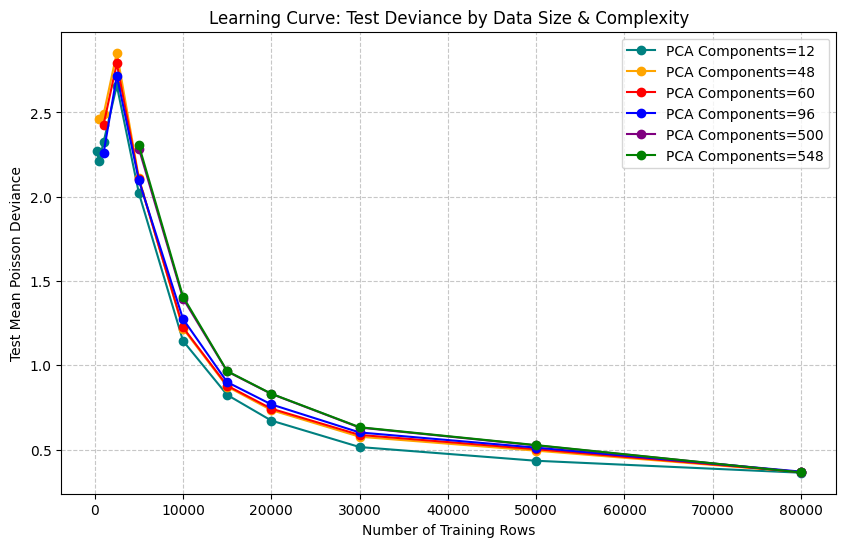

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import gc

# -------------------------------------------------------
# Setup & Split
# -------------------------------------------------------
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})

y_train = meta_train['ClaimNb']
offset_train = meta_train['Exposure']

meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

y_test = meta_test['ClaimNb']
offset_test = meta_test['Exposure']


# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
# Define a comprehensive list of sizes (sorted)
# Includes 200, 1000, and then jumps to 5000, 10000...
train_sizes = [200, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 50000, 80000]

# Define when each model is allowed to start
start_thresholds = {
    12: 200,
    48: 500,   
    60: 1000,
    96: 1000,
    500: 5000,  # Strictly enforce 500 components starting at 5000 rows
    548: 5000
}

component_sets = [12, 48, 60, 96, 500, 548]
results_history = {k: [] for k in component_sets}



# -------------------------------------------------------
# Learning Curve Loop
# -------------------------------------------------------
for size in train_sizes:
    print(f"Processing Training Size: {size}")
    
    # --- Slice Data ---
    X_train_sub = X_train.iloc[:size].copy()
    y_train_sub = y_train.iloc[:size]
    off_train_sub = offset_train.iloc[:size]
    
    # --- Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test)

    del X_train_sub, scaler
    gc.collect()
    
    # --- PCA (Dynamic Fitting) ---
    # We cannot compute 500 components if we only have 200 rows.
    # We fit the maximum possible for this specific iteration.
    n_features = X_train_scaled.shape[1]
    max_k_possible = min(size, n_features, 548)
    
    pca = PCA(n_components=max_k_possible, random_state = 42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)

    del X_train_scaled, X_test_scaled, pca
    gc.collect()

    # --- Loop through component configurations ---
    for k in component_sets:
        
        # Check 1: User-defined Start Rule (e.g., Don't run 500 if size < 5000)
        if size < start_thresholds[k]:
            results_history[k].append(np.nan)
            continue

        # Check 2: Mathematical Rule (Can't extract 48 components from 12 features)
        if k > max_k_possible:
            results_history[k].append(np.nan)
            continue
            
        # Slice the required components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        # Fit GLM
        try:
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            # Score
            mpd = mean_poisson_deviance(y_test, preds)
            results_history[k].append(mpd)
            
        except Exception as e:
            print(f"  Failed for k={k} at size={size}: {e}")
            results_history[k].append(np.nan)

        del X_train_k, X_test_k
        gc.collect()

# -------------------------------------------------------
# Plotting
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

colors = {12: 'teal', 48: 'orange', 60: 'red', 96: 'blue', 500: 'purple', 548: 'green'}

for k in component_sets:
    # We filter out NaNs so the line connects properly for available data points
    # or keeps gaps where data is missing
    sizes_valid = [s for s, r in zip(train_sizes, results_history[k]) if not np.isnan(r)]
    scores_valid = [r for r in results_history[k] if not np.isnan(r)]
    
    plt.plot(sizes_valid, scores_valid, marker='o', linestyle='-', 
             color=colors.get(k, 'black'), label=f'PCA Components={k}')

plt.title('Learning Curve: Test Deviance by Data Size & Complexity')
plt.xlabel('Number of Training Rows')
#plt.xscale('log')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
#plt.savefig('lc_comp_pca_fix.png')
plt.show()

## Learning Curves

Size 500: 2.46883
Size 1077: 2.47236
Size 2320: 2.81593
Size 4999: 2.10814
Size 10772: 1.14770
Size 23207: 0.65678
Size 49999: 0.49360
Size 107721: 0.35383
Size 232079: 0.32151
Size 500000: 0.31156


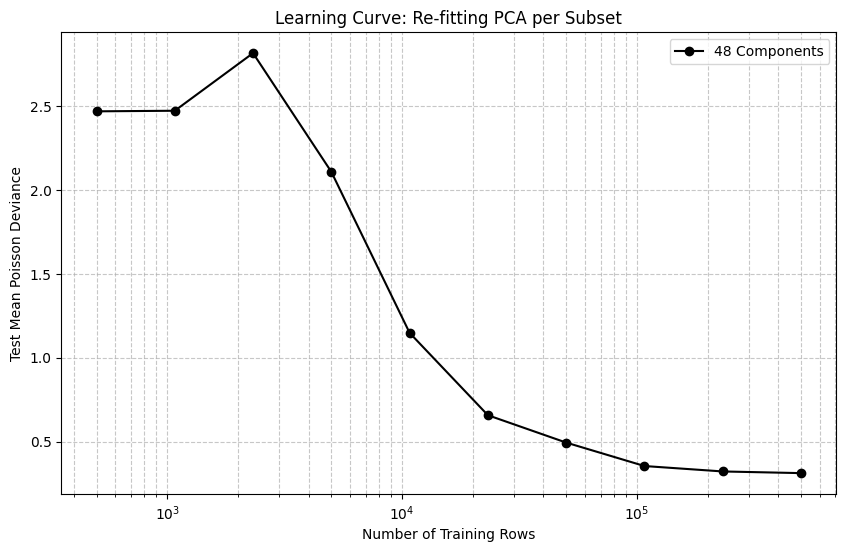

In [11]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import matplotlib.pyplot as plt
# -------------------------------------------------------
# Setup (Using raw X data before PCA)
# -------------------------------------------------------
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

y_train = meta_train['ClaimNb']
offset_train = meta_train['Exposure']

y_test = meta_test['ClaimNb']
offset_test = meta_test['Exposure']

# Learning Curve Loop
# -------------------------------------------------------
train_sizesr = np.geomspace(500, 500000, num=10, dtype=int)
deviancesr_2 = []
n_components = 48  # Define target components here

for size in train_sizesr:
    # Slice the first 'size' rows from RAW data
    X_train_sub_raw = X_train[:size]
    y_train_sub = y_train[:size]
    off_train_sub = offset_train[:size]
    
    # Fit PCA on the current training subset only
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_sub_raw)
    
    # Transform the FIXED Test set using the PCA fitted on the subset
    X_test_pca = pca.transform(X_test)
    
    # Add constants for Statsmodels
    X_train_glm = sm.add_constant(X_train_pca)
    X_test_glm = sm.add_constant(X_test_pca, has_constant='add')
    
    # Fit GLM
    # Note: Use np.log() for the offset in Poisson GLM
    glm = sm.GLM(
        endog=y_train_sub, 
        exog=X_train_glm, 
        offset=np.log(off_train_sub), 
        family=sm.families.Poisson()
    )
    results = glm.fit()
    
    # Predict on transformed Test Set
    preds = results.predict(exog=X_test_glm, offset=np.log(offset_test))
    
    # Score
    mpd = mean_poisson_deviance(y_test, preds)
    deviancesr_2.append(mpd)
    print(f"Size {size}: {mpd:.5f}")

# -------------------------------------------------------
# 3. Plotting 
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(train_sizesr, deviancesr_2, marker='o', color='black', label=f'{n_components} Components')
plt.xscale('log')
plt.title('Learning Curve: Re-fitting PCA per Subset')
plt.xlabel('Number of Training Rows')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()

Textbook beating fine tuned GLM at 48 embeddings, embeddings better at 60 and 96. 48 components does start out much lower than raw data, and appears to be decreasing at a greater rate approaching 40k rows of data (jump of 0.00115 vs 0.00078), so likely has more room for improvement with more data